# Frontal-Plane Axis Rotation Demo

This notebook loads a preprocessed 12-lead ECG `.pt` tensor, applies a small frontal-plane
axis rotation (via an approximate 12-lead → Frank XYZ → rotate → 12-lead pipeline), and plots
the original vs rotated signals.

Notes:
- This is still an approximation: 12-lead ECG does not uniquely determine the 3D cardiac vector.
- We use a linear 12-lead→VCG transform and a pseudo-inverse to map back, so results are a plausible
  augmentation rather than a strict physiological simulator.
- Adjust `lead_order` if your channel ordering differs.


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import neurokit2 as nk

# Paths to three ECG tensors saved as .pt (shape [C,T] or [1,C,T])
ecg_samples = [
    {
        "path": "/home/flo178/projects/master-thesis/datasets/physionet2025/processedMaster/bp/1412187.pt",
        "label": "CODE-15 healthy",
    },
    {
        "path": "/home/flo178/projects/master-thesis/datasets/physionet2025/processedMaster/bp/13625_hr.pt",
        "label": "PTB-XL healthy",
    },
    {
        "path": "/home/flo178/projects/master-thesis/datasets/physionet2025/processedMaster/bp/137001.pt",
        "label": "SaMi-Trop Chagas",
    },
]

ecgs = []
for sample in ecg_samples:
    ecg_i = torch.load(sample["path"])
    if ecg_i.ndim == 3:
        ecg_i = ecg_i[0]
    ecgs.append(ecg_i.detach().cpu().numpy())

for i, (e, sample) in enumerate(zip(ecgs, ecg_samples)):
    print(f"ECG {i} ({sample['label']}) shape: {e.shape}")

# Adjust this if your channel ordering differs
lead_order = ["I", "II", "III", "aVR", "aVL", "aVF", "V1", "V2", "V3", "V4", "V5", "V6"]

# Which ECG to visualize in 2D lead plots
plot_idx = 2
ecg = ecgs[plot_idx]

# Set this to your dataset sampling rate (Hz)
sampling_rate = 400


ECG 0 (CODE-15 healthy) shape: (12, 4096)
ECG 1 (PTB-XL healthy) shape: (12, 4000)
ECG 2 (SaMi-Trop Chagas) shape: (12, 2934)


In [81]:
def _frank_matrix_from_wikipedia():
    """Return the linear transform A mapping [I, II, V1..V6] -> [X, Y, Z].

    This matches the coefficients used in compute_frank_xyz() below (Wikipedia / Dower-like).
    Shape: (3, 8).
    """
    # Lead vector L := [I, II, V1, V2, V3, V4, V5, V6]^T
    # X =  0.172*V1 + 0.074*V2 - 0.122*V3 - 0.231*V4 - 0.239*V5 - 0.194*V6 - 0.156*I + 0.010*II
    # Y =  0.057*V1 - 0.019*V2 - 0.106*V3 - 0.022*V4 + 0.041*V5 + 0.048*V6 - 0.227*I + 0.887*II
    # Z =  0.229*V1 + 0.310*V2 + 0.246*V3 + 0.063*V4 - 0.055*V5 - 0.108*V6 - 0.022*I - 0.102*II
    A = np.array(
        [
            [-0.156, 0.010, 0.172, 0.074, -0.122, -0.231, -0.239, -0.194],
            [-0.227, 0.887, 0.057, -0.019, -0.106, -0.022, 0.041, 0.048],
            [-0.022, -0.102, 0.229, 0.310, 0.246, 0.063, -0.055, -0.108],
        ],
        dtype=float,
    )
    return A


def _get_ii_v1v6_vector(ecg_in, lead_order):
    idx = {name: i for i, name in enumerate(lead_order)}
    needed = ["I", "II", "V1", "V2", "V3", "V4", "V5", "V6"]
    for name in needed:
        if name not in idx:
            raise ValueError(f"Missing lead '{name}' in lead_order")
    return np.stack([ecg_in[idx[name]] for name in needed], axis=0), idx


def rotate_vcg_frontal_plane_12lead(ecg_in, angle_deg, lead_order):
    """Approximate a frontal-plane axis rotation by rotating Frank XYZ around Z.

    Pipeline: 12-lead -> (approx) Frank XYZ -> rotate about Z (frontal plane) -> back to 12-lead.
    Since 12-lead -> XYZ is lossy, we keep the original null-space residual so that angle=0°
    reproduces the input exactly.

    ecg_in: [C, T] numpy array
    angle_deg: rotation angle in degrees (positive = CCW in X-Y)
    lead_order: list of lead names matching channel order
    """
    ecg_out = ecg_in.copy()

    L, idx = _get_ii_v1v6_vector(ecg_in, lead_order)  # [8, T]
    A = _frank_matrix_from_wikipedia()  # [3, 8]
    A_pinv = np.linalg.pinv(A)  # [8, 3]

    XYZ = A @ L  # [3, T]
    L_proj = A_pinv @ XYZ  # [8, T]
    residual = L - L_proj

    theta = np.deg2rad(angle_deg)
    c, s = np.cos(theta), np.sin(theta)
    Rz = np.array([[c, -s, 0.0], [s, c, 0.0], [0.0, 0.0, 1.0]], dtype=float)  # [3, 3]
    XYZ_rot = Rz @ XYZ

    L_rot = (A_pinv @ XYZ_rot) + residual

    # Write back I, II, V1..V6
    for name, sig in zip(["I", "II", "V1", "V2", "V3", "V4", "V5", "V6"], L_rot):
        ecg_out[idx[name]] = sig

    # Enforce limb-lead identities for the remaining limb leads
    I_rot = ecg_out[idx["I"]]
    II_rot = ecg_out[idx["II"]]
    III_rot = II_rot - I_rot
    aVR_rot = -(I_rot + II_rot) / 2.0
    aVL_rot = I_rot - 0.5 * II_rot
    aVF_rot = II_rot - 0.5 * I_rot

    for name, sig in [
        ("III", III_rot),
        ("aVR", aVR_rot),
        ("aVL", aVL_rot),
        ("aVF", aVF_rot),
    ]:
        if name in idx:
            ecg_out[idx[name]] = sig

    return ecg_out


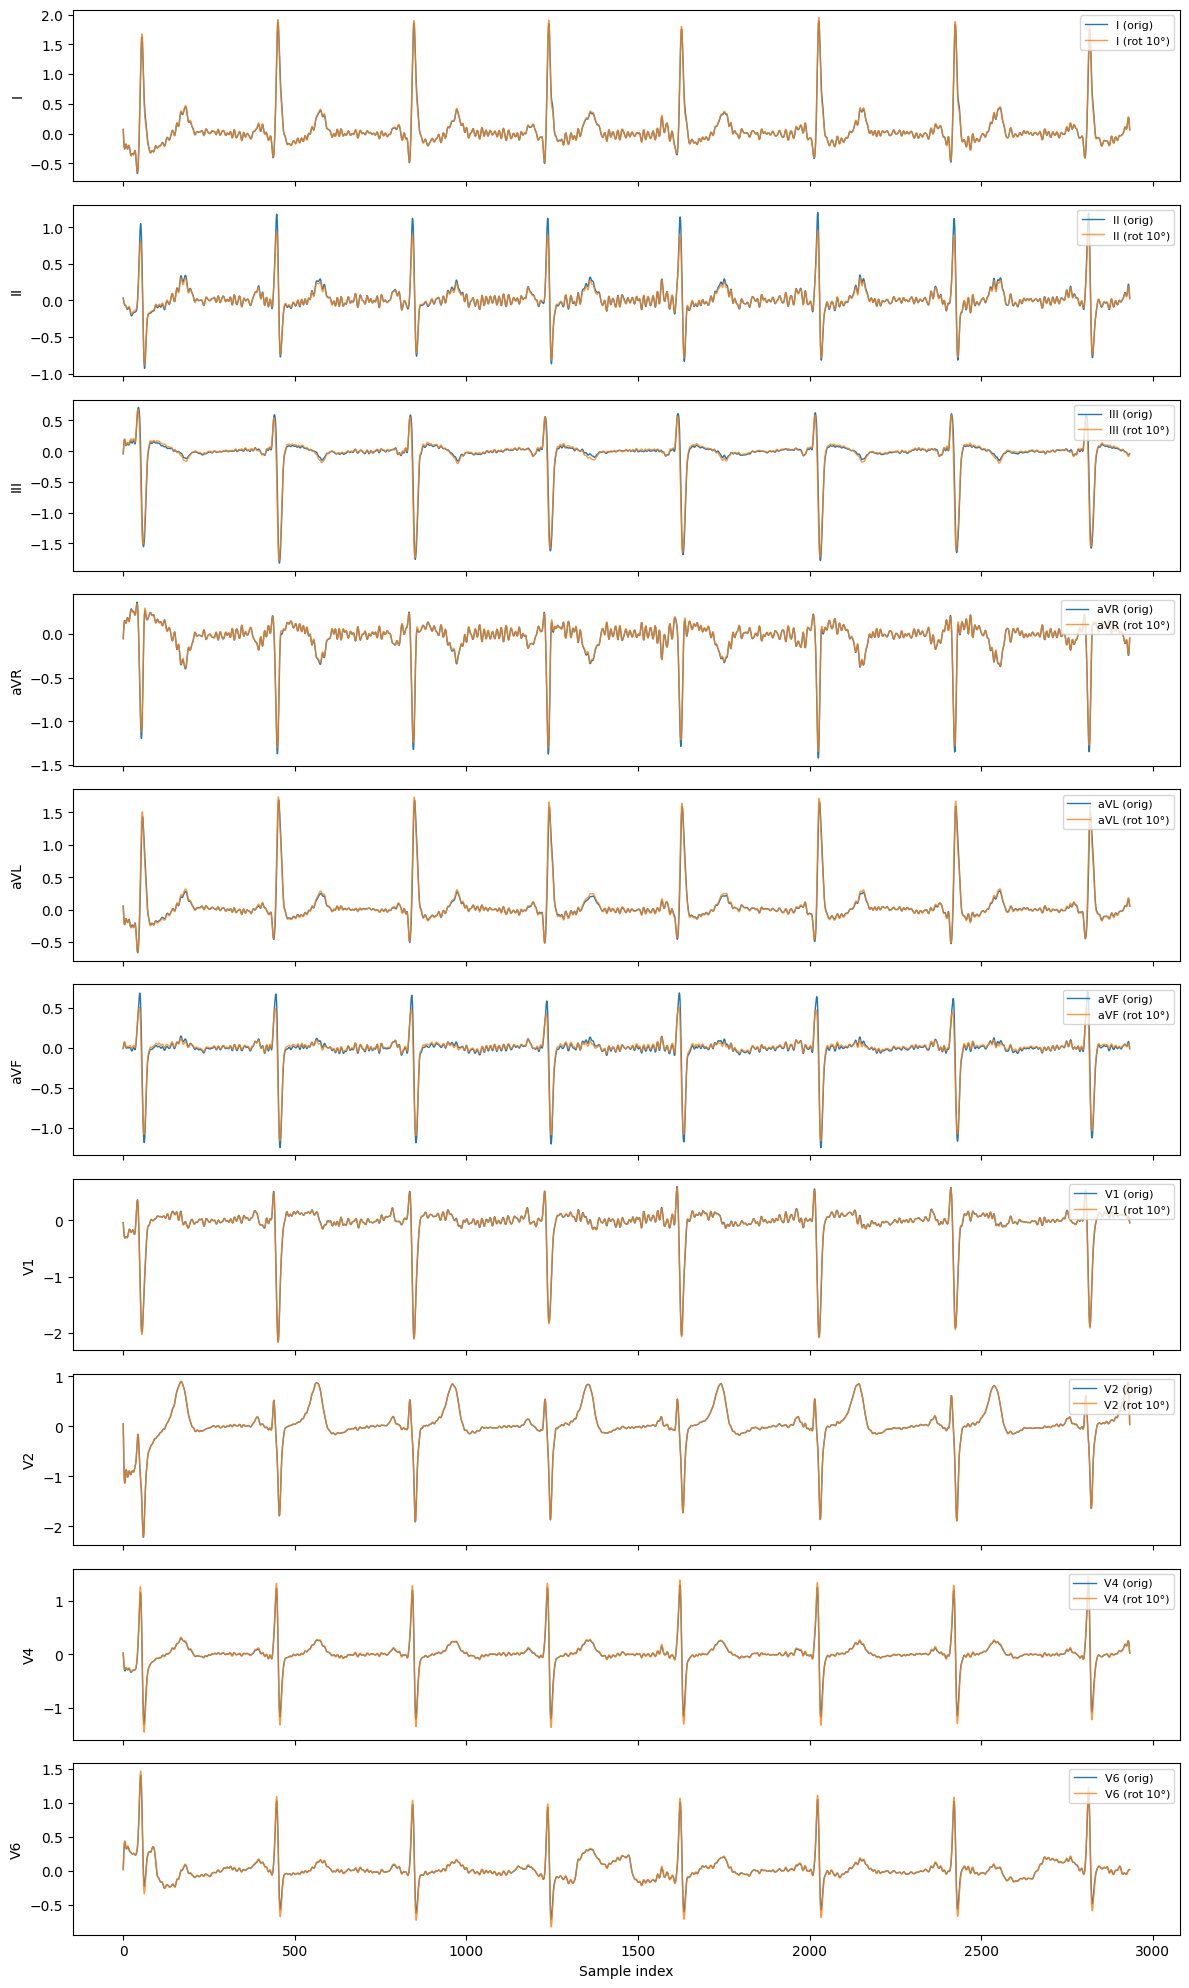

In [82]:
angle_deg = 10  # rotation angle for frontal-plane demo
ecg_rots = [rotate_vcg_frontal_plane_12lead(e, angle_deg, lead_order) for e in ecgs]
ecg_rot = ecg_rots[plot_idx]

# Plot a subset of leads
plot_leads = ["I", "II", "III", "aVR", "aVL", "aVF", "V1", "V2", "V4", "V6"]
n = len(plot_leads)
fig, axes = plt.subplots(n, 1, figsize=(12, 2 * n), sharex=True)
if n == 1:
    axes = [axes]

t = np.arange(ecg.shape[1])
for ax, name in zip(axes, plot_leads):
    idx = lead_order.index(name)
    ax.plot(t, ecg[idx], label=f"{name} (orig)", linewidth=1)
    ax.plot(t, ecg_rot[idx], label=f"{name} (rot {angle_deg}°)", linewidth=1, alpha=0.8)
    ax.set_ylabel(name)
    ax.legend(loc="upper right", fontsize=8)

axes[-1].set_xlabel("Sample index")
plt.tight_layout()


In [ ]:
def _wrap_delta_deg(delta_deg):
    return (delta_deg + 180.0) % 360.0 - 180.0


def _circular_mean_deg(angles_deg):
    angles_deg = np.asarray(list(angles_deg), dtype=float)
    if angles_deg.size == 0:
        return None
    ang = np.deg2rad(angles_deg)
    return float(np.degrees(np.arctan2(np.mean(np.sin(ang)), np.mean(np.cos(ang)))))


def estimate_frontal_axis_deg_peak2peak(ecg_in, lead_order):
    """Very rough axis proxy from peak-to-peak over the whole segment (kept for comparison)."""
    idx = {name: i for i, name in enumerate(lead_order)}
    I = ecg_in[idx["I"]]  # noqa: E741
    II = ecg_in[idx["II"]]
    aVF = II - 0.5 * I
    vec_I = I.max() - I.min()
    vec_aVF = aVF.max() - aVF.min()
    return float(np.degrees(np.arctan2(vec_aVF, vec_I)))


def estimate_frontal_axis_vcg_xy_deg_qrs(
    ecg_in,
    lead_order,
    sampling_rate,
    *,
    rpeak_lead="II",
    qrs_window_ms=(-80, 80),
    max_beats=20,
):
    """Estimate frontal axis from Frank VCG X-Y using NeuroKit2 R-peaks.

    This should track the applied rotation much better than peak-to-peak on full segments.
    Returns angle in degrees (atan2(Y, X)) or None if estimation fails.
    """
    if nk is None:
        return None

    idx = {name: i for i, name in enumerate(lead_order)}
    if rpeak_lead not in idx:
        raise ValueError(f"Missing lead '{rpeak_lead}' in lead_order")

    sig = ecg_in[idx[rpeak_lead]].astype(float)
    try:
        _, info = nk.ecg_peaks(sig, sampling_rate=sampling_rate)
        rpeaks = list(info.get("ECG_R_Peaks", []))
    except Exception:
        return None

    if not rpeaks:
        return None

    pre = int(round(abs(qrs_window_ms[0]) * sampling_rate / 1000.0))
    post = int(round(abs(qrs_window_ms[1]) * sampling_rate / 1000.0))

    L, _ = _get_ii_v1v6_vector(ecg_in, lead_order)  # [8, T]
    A = _frank_matrix_from_wikipedia()  # [3, 8]
    XYZ = A @ L
    X = XYZ[0]
    Y = XYZ[1]

    angles = []
    for r in rpeaks[: max_beats * 2]:
        if r - pre < 0 or r + post >= sig.shape[0]:
            continue
        x = float(np.mean(X[r - pre : r + post]))
        y = float(np.mean(Y[r - pre : r + post]))
        if x == 0.0 and y == 0.0:
            continue
        angles.append(np.degrees(np.arctan2(y, x)))
        if len(angles) >= max_beats:
            break

    return _circular_mean_deg(angles)


print("Estimated frontal axis (deg):")
print("- VCG-QRS: NeuroKit2 R-peaks, mean Frank X-Y in QRS window")
print("- P2P: peak-to-peak over full segment (very rough)")
for i, (e_orig, e_rot) in enumerate(zip(ecgs, ecg_rots)):
    ang_o_vcg = estimate_frontal_axis_vcg_xy_deg_qrs(e_orig, lead_order, sampling_rate)
    ang_r_vcg = estimate_frontal_axis_vcg_xy_deg_qrs(e_rot, lead_order, sampling_rate)
    if ang_o_vcg is not None and ang_r_vcg is not None:
        d_vcg = _wrap_delta_deg(ang_r_vcg - ang_o_vcg)
        vcg_msg = f"VCG-QRS orig={ang_o_vcg:.1f}°, rot={ang_r_vcg:.1f}° (Δ={d_vcg:+.1f}°, target≈{angle_deg:+.1f}°)"
    else:
        vcg_msg = "VCG-QRS (unavailable)"

    ang_o_p2p = estimate_frontal_axis_deg_peak2peak(e_orig, lead_order)
    ang_r_p2p = estimate_frontal_axis_deg_peak2peak(e_rot, lead_order)
    d_p2p = _wrap_delta_deg(ang_r_p2p - ang_o_p2p)
    print(f"ECG {i}: {vcg_msg} | P2P Δ={d_p2p:+.1f}°")


Estimated frontal axis (deg):
- VCG-QRS: NeuroKit2 R-peaks, mean Frank X-Y in QRS window
- P2P: peak-to-peak over full segment (very rough)
ECG 0: VCG-QRS orig=84.8°, rot=94.8° (Δ=+10.0°, target≈+10.0°) | P2P Δ=-9.3°
ECG 1: VCG-QRS orig=156.1°, rot=166.1° (Δ=+10.0°, target≈+10.0°) | P2P Δ=-16.6°
ECG 2: VCG-QRS orig=-161.5°, rot=-151.5° (Δ=+10.0°, target≈+10.0°) | P2P Δ=-4.5°


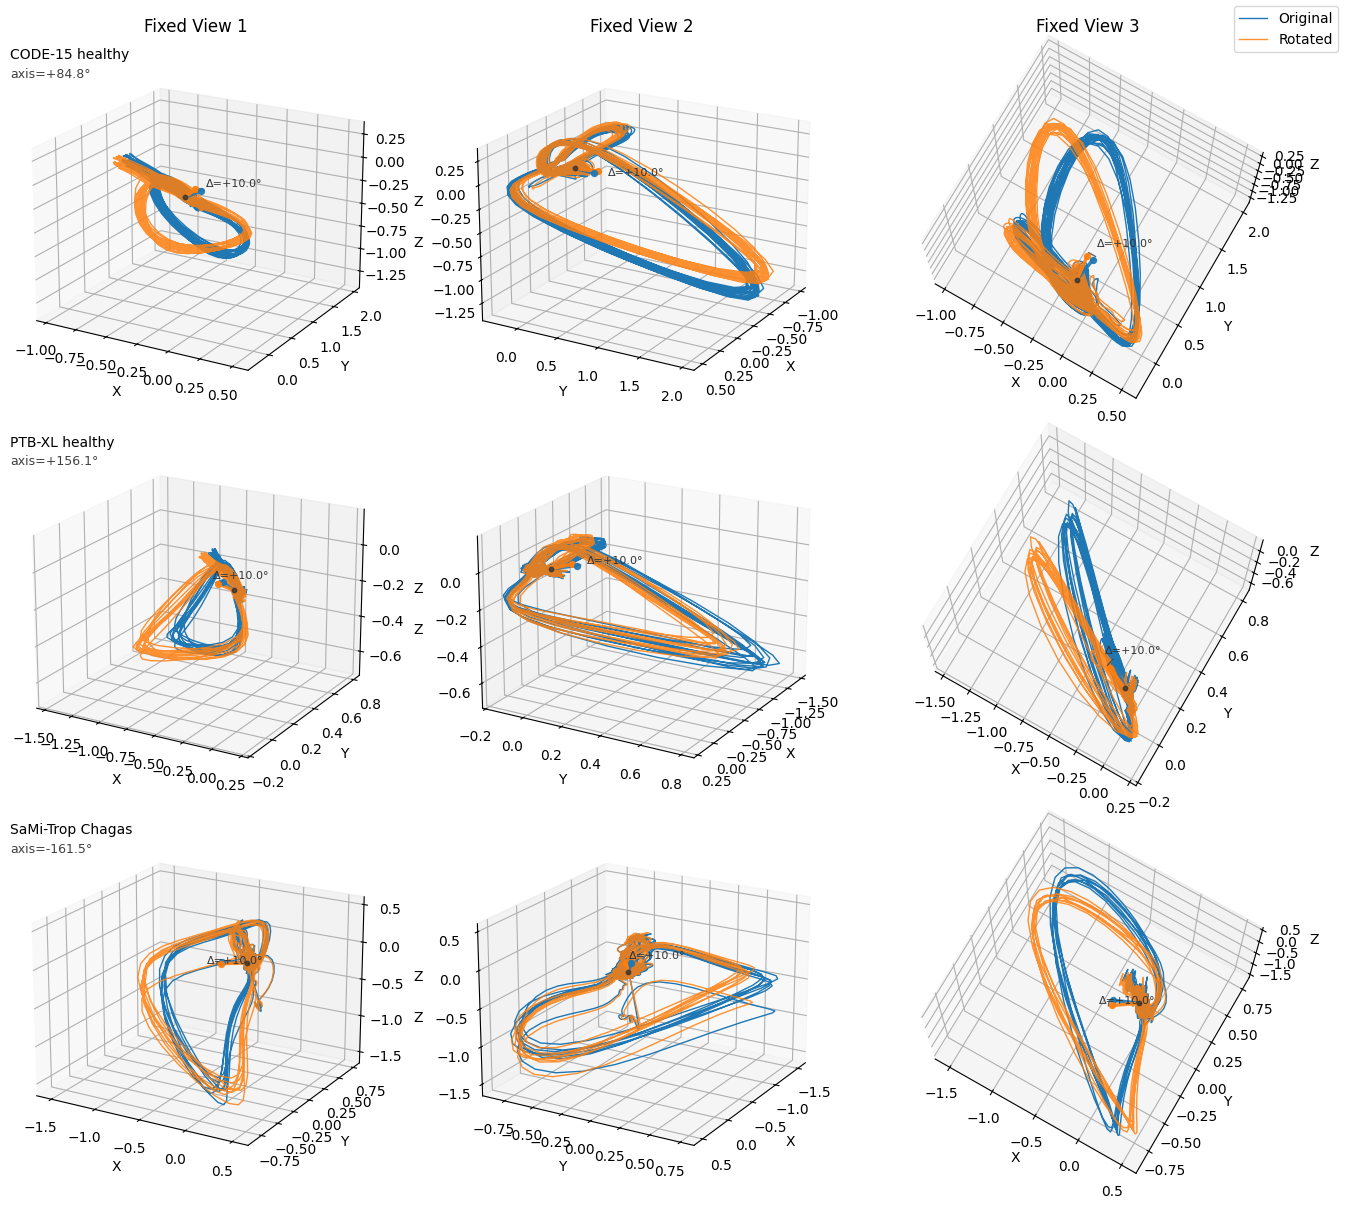

In [ ]:
def compute_frank_xyz(ecg_in, lead_order):
    """Compute Frank XYZ from 12-lead ECG using a linear approximation.
    This uses the coefficients from Wikipedia (Dower-like transform).
    """
    L, _ = _get_ii_v1v6_vector(ecg_in, lead_order)  # [8, T]
    A = _frank_matrix_from_wikipedia()  # [3, 8]
    XYZ = A @ L  # [3, T]
    X, Y, Z = XYZ
    return X, Y, Z

def _get_rpeaks_neurokit(ecg_in, lead_order, sampling_rate, *, rpeak_lead="II"):
    if nk is None:
        return None
    idx = {name: i for i, name in enumerate(lead_order)}
    if rpeak_lead not in idx:
        raise ValueError(f"Missing lead '{rpeak_lead}' in lead_order")
    sig = ecg_in[idx[rpeak_lead]].astype(float)
    try:
        _, info = nk.ecg_peaks(sig, sampling_rate=sampling_rate)
        rpeaks = list(info.get("ECG_R_Peaks", []))
        return rpeaks
    except Exception:
        return None


def estimate_frontal_axis_vcg_xy_unit_vector_qrs(
    ecg_in,
    lead_order,
    sampling_rate,
    rpeaks,
    *,
    qrs_window_ms=(-80, 80),
    max_beats=20,
):
    """Unit frontal axis vector from Frank VCG X-Y on QRS windows."""
    if not rpeaks:
        return None
    pre = int(round(abs(qrs_window_ms[0]) * sampling_rate / 1000.0))
    post = int(round(abs(qrs_window_ms[1]) * sampling_rate / 1000.0))

    L, _ = _get_ii_v1v6_vector(ecg_in, lead_order)  # [8, T]
    A = _frank_matrix_from_wikipedia()  # [3, 8]
    XYZ = A @ L
    X = XYZ[0]
    Y = XYZ[1]

    vx_sum = 0.0
    vy_sum = 0.0
    used = 0
    for r in rpeaks[: max_beats * 2]:
        if r - pre < 0 or r + post >= X.shape[0]:
            continue
        x = float(np.mean(X[r - pre : r + post]))
        y = float(np.mean(Y[r - pre : r + post]))
        norm = np.hypot(x, y)
        if norm == 0.0:
            continue
        vx_sum += x / norm
        vy_sum += y / norm
        used += 1
        if used >= max_beats:
            break

    if used == 0:
        return None
    norm = np.hypot(vx_sum, vy_sum) or 1.0
    return vx_sum / norm, vy_sum / norm

# 3x3 grid: rows = ECG samples, cols = 3 fixed views (same camera for all rows)
# This makes between-patient differences in loop orientation easier to compare.
view_mode = "fixed"  # "fixed" or "axis_aligned"
fixed_views = [
    (20, -60),
    (20, 30),
    (75, -60),
]
titles = ["Fixed View 1", "Fixed View 2", "Fixed View 3"]

fig = plt.figure(figsize=(14, 12))
for row_idx, (e_orig, e_rot) in enumerate(zip(ecgs, ecg_rots)):
    xyz_orig = compute_frank_xyz(e_orig, lead_order)
    xyz_rot = compute_frank_xyz(e_rot, lead_order)

    # Axis vectors estimated in Frank VCG X-Y on QRS windows (uses NeuroKit2 R-peaks).
    rpeaks = _get_rpeaks_neurokit(e_orig, lead_order, sampling_rate, rpeak_lead="II")
    v_orig = estimate_frontal_axis_vcg_xy_unit_vector_qrs(e_orig, lead_order, sampling_rate, rpeaks)
    v_rot = estimate_frontal_axis_vcg_xy_unit_vector_qrs(e_rot, lead_order, sampling_rate, rpeaks)
    if v_orig is None or v_rot is None:
        # Fallback: use the full-segment peak-to-peak proxy in I/aVF.
        idx = {name: i for i, name in enumerate(lead_order)}
        I = e_orig[idx["I"]]  # noqa: E741
        II = e_orig[idx["II"]]
        aVF = II - 0.5 * I
        vec_I = I.max() - I.min()
        vec_aVF = aVF.max() - aVF.min()
        norm = np.hypot(vec_I, vec_aVF) or 1.0
        v_orig = (vec_I / norm, vec_aVF / norm)
        v_rot = v_orig

    ax_x, ax_y = v_orig
    ax_x_rot, ax_y_rot = v_rot
    base_azim = np.degrees(np.arctan2(ax_y, ax_x))
    if view_mode == "axis_aligned":
        titles = ["Axis-Aligned View", "Axis-Aligned +45°", "Axis-Aligned +135°"]
        views = [
            (0, base_azim),
            (20, base_azim + 45),
            (60, base_azim + 135),
        ]
    else:
        views = fixed_views

    # Arrow/arc sizing based on trajectory extent (keeps annotations subtle)
    x0, y0, z0 = xyz_orig
    span = float(
        max(
            np.ptp(x0),
            np.ptp(y0),
            np.ptp(z0),
        )
    )
    anchor = (float(np.mean(x0)), float(np.mean(y0)), float(np.mean(z0)))
    arrow_len = max(0.12 * span, 1e-6)

    # Rotation angle between axis vectors in the X-Y plane
    ang0 = float(np.arctan2(ax_y, ax_x))
    ang1 = float(np.arctan2(ax_y_rot, ax_x_rot))
    d_ang = float((ang1 - ang0 + np.pi) % (2 * np.pi) - np.pi)

    for col_idx, (elev, azim) in enumerate(views):
        ax = fig.add_subplot(3, 3, row_idx * 3 + col_idx + 1, projection="3d")
        ax.plot(*xyz_orig, label="Original", linewidth=1, color="C0")
        ax.plot(*xyz_rot, label="Rotated", linewidth=1, alpha=0.85, color="C1")

        # Axis annotation: short line segments + a small arc indicating Δ in the X-Y plane.
        # (3D quiver can be hard to see depending on view; lines are more reliable.)
        # Colors match Matplotlib's default cycle (C0=blue, C1=orange).
        xa, ya, za = anchor
        x_end0 = xa + arrow_len * ax_x
        y_end0 = ya + arrow_len * ax_y
        x_end1 = xa + arrow_len * ax_x_rot
        y_end1 = ya + arrow_len * ax_y_rot
        ax.plot([xa, x_end0], [ya, y_end0], [za, za], color="C0", linewidth=2.5, alpha=0.9)
        ax.plot([xa, x_end1], [ya, y_end1], [za, za], color="C1", linewidth=2.5, alpha=0.9)
        ax.scatter([xa], [ya], [za], color="0.2", s=10, alpha=0.8)
        ax.scatter([x_end0], [y_end0], [za], color="C0", s=18, alpha=0.9)
        ax.scatter([x_end1], [y_end1], [za], color="C1", s=18, alpha=0.9)

        # Arc drawn around the anchor (in the X-Y plane) to show the rotation magnitude
        r = 1.15 * arrow_len
        arc = np.linspace(ang0, ang0 + d_ang, 40)
        ax.plot(
            xa + r * np.cos(arc),
            ya + r * np.sin(arc),
            np.full_like(arc, za),
            color="0.25",
            linewidth=1.0,
            alpha=0.8,
        )
        mid = ang0 + 0.5 * d_ang
        ax.text(
            xa + 1.35 * r * np.cos(mid),
            ya + 1.35 * r * np.sin(mid),
            za,
            f"Δ={np.degrees(d_ang):+.1f}°",
            color="0.2",
            fontsize=8,
        )
        ax.set_xlabel("X")
        ax.set_ylabel("Y")
        ax.set_zlabel("Z")
        ax.view_init(elev=elev, azim=azim)
        if row_idx == 0:
            ax.set_title(titles[col_idx])
        if col_idx == 0:
            ax.text2D(0.0, 0.95, ecg_samples[row_idx]['label'], transform=ax.transAxes)
            ax.text2D(0.0, 0.90, f"axis={base_azim:+.1f}°", transform=ax.transAxes, fontsize=9, color="0.25")

# Single shared legend
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")
plt.tight_layout()
